# OCTA-500 Capillary: Classical Baseline vs. U-Net

Grid-searches the classical adaptive-threshold baseline (raw, CLAHE-preprocessed,
and a Meijering-vesselness-enhanced variant), then compares it against a plain
U-Net trained via `src/train.run_kfold` on the same held-out 40-image test set.
Ends with the head-to-head metrics table used elsewhere in the writeup.

Loads a pre-FlexUNet-refactor checkpoint, so the U-Net cell goes through
`model.remap_legacy_state_dict` to match today's `FlexUNet` key names.


In [1]:
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')

import cv2
import matplotlib.pyplot as plt

from dataset import get_octa500_split
from classical_baseline import apply_preprocessing, cv_grid_search, evaluate_on_test

train_imgs, train_masks, test_imgs, test_masks = get_octa500_split()
print(f"train {len(train_imgs)}   test {len(test_imgs)}")
assert train_imgs[0].exists() and train_masks[0].exists(), "check paths in get_octa500_split()"

train 160   test 40


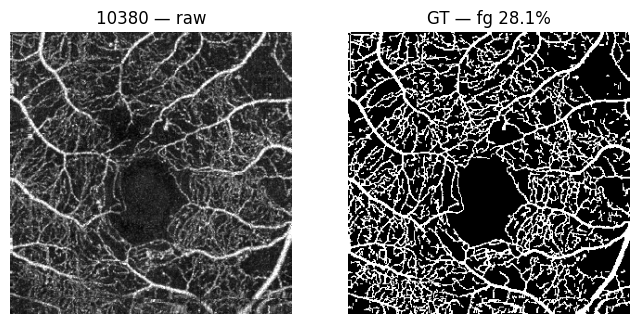

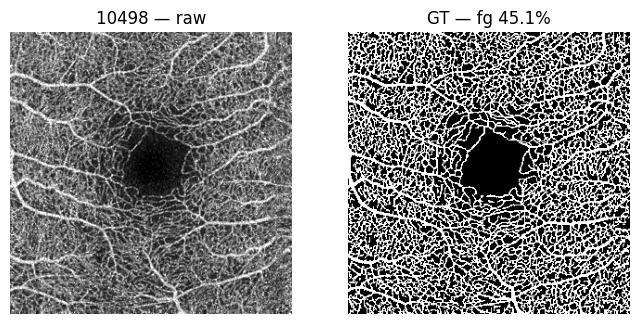

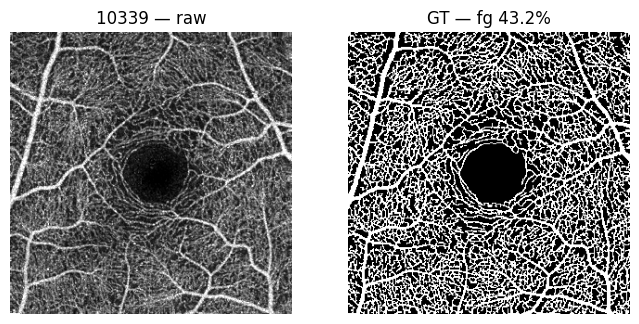

image shape: (304, 304)


In [2]:
for p_img, p_gt in list(zip(train_imgs, train_masks))[:3]:
    img = cv2.imread(str(p_img), cv2.IMREAD_GRAYSCALE)
    gt  = cv2.imread(str(p_gt),  cv2.IMREAD_GRAYSCALE)
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(img, cmap='gray'); ax[0].set_title(f"{p_img.stem} — raw"); ax[0].axis('off')
    ax[1].imshow(gt,  cmap='gray'); ax[1].set_title(f"GT — fg {(gt > 127).mean():.1%}"); ax[1].axis('off')
    plt.show()
print("image shape:", cv2.imread(str(train_imgs[0]), cv2.IMREAD_GRAYSCALE).shape)

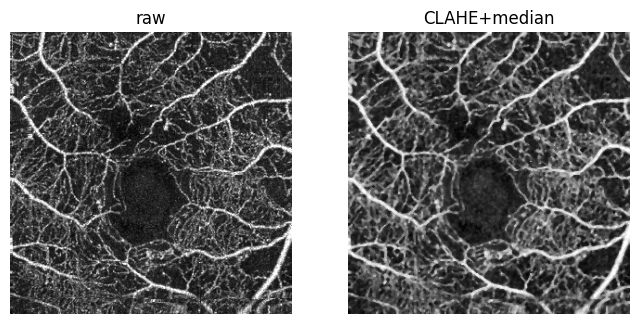

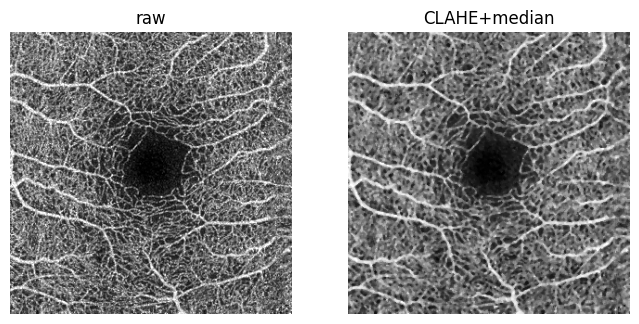

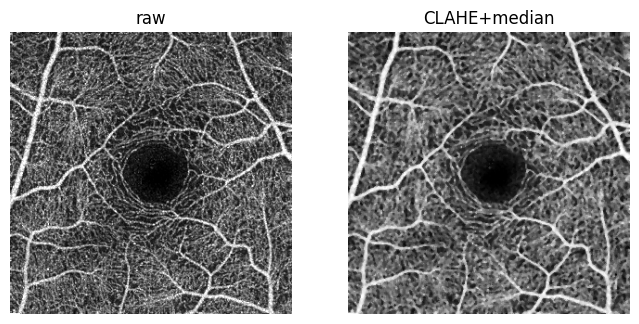

In [3]:
for p_img, _ in list(zip(train_imgs, train_masks))[:3]:
    img = cv2.imread(str(p_img), cv2.IMREAD_GRAYSCALE)
    pre = apply_preprocessing(img, clip=2.0, tile=4)
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(img, cmap='gray'); ax[0].set_title("raw");          ax[0].axis('off')
    ax[1].imshow(pre, cmap='gray'); ax[1].set_title("CLAHE+median"); ax[1].axis('off')
    plt.show()

In [5]:
# block_size must be ODD. Small sizes added for dense capillary scale.
block_sizes = [7, 11, 21, 31, 51, 71, 101]
c_values    = [-40, -30, -20, -10, -5, 0, 5]

raw_block, raw_C, raw_results = cv_grid_search(
    train_imgs, train_masks, block_sizes, c_values)                    # raw
pre_block, pre_C, pre_results = cv_grid_search(
    train_imgs, train_masks, block_sizes, c_values, clip=2.0, tile=4)  # preprocessed

for tag, b, c in [("raw", raw_block, raw_C), ("preprocessed", pre_block, pre_C)]:
    edge = b in (block_sizes[0], block_sizes[-1]) or c in (c_values[0], c_values[-1])
    flag = "   <-- optimum at grid edge: widen the range and rerun" if edge else ""
    print(f"{tag:13s} best block={b}  C={c}{flag}")

raw           best block=21  C=-10
preprocessed  best block=11  C=-5


In [6]:
raw_mean, raw_std = evaluate_on_test(test_imgs, test_masks, raw_block, raw_C)
pre_mean, pre_std = evaluate_on_test(test_imgs, test_masks, pre_block, pre_C, clip=2.0, tile=4)

print("OCTA-500 classical baseline — held-out 40 test images\n")
print(f"{'metric':13s} {'raw':>18s} {'preprocessed':>18s}")
print("-" * 52)
for k in raw_mean:
    print(f"{k:13s} {raw_mean[k]:.4f}±{raw_std[k]:.4f}   {pre_mean[k]:.4f}±{pre_std[k]:.4f}")

OCTA-500 classical baseline — held-out 40 test images

metric                       raw       preprocessed
----------------------------------------------------
dice          0.7894±0.0188   0.7590±0.0196
iou           0.6524±0.0248   0.6120±0.0246
sensitivity   0.8334±0.0324   0.7899±0.0364
specificity   0.8018±0.0152   0.7939±0.0072
precision     0.7526±0.0413   0.7344±0.0460


In [ ]:
from skimage.filters import frangi, meijering
import numpy as np

def to01(x):
    x = x.astype(np.float32)
    return (x - x.min()) / (np.ptp(x) + 1e-8)

for p_img, p_gt in list(zip(train_imgs, train_masks))[:3]:
    img = cv2.imread(str(p_img), cv2.IMREAD_GRAYSCALE)
    gt  = cv2.imread(str(p_gt),  cv2.IMREAD_GRAYSCALE)
    imgf = img.astype(np.float32) / 255.0

    clahe = apply_preprocessing(img, clip=2.0, tile=4)
    # OCTA vessels are BRIGHT on a dark background -> black_ridges=False
    frg = frangi(imgf, sigmas=range(1, 4), black_ridges=False)
    mei = meijering(imgf, sigmas=range(1, 4), black_ridges=False)

    fig, ax = plt.subplots(1, 5, figsize=(20, 4))
    for a, im, t in zip(ax, [img, clahe, to01(frg), to01(mei), gt],
                        ["raw", "CLAHE+median", "Frangi", "Meijering", "GT"]):
        a.imshow(im, cmap='gray'); a.set_title(t); a.axis('off')
    plt.show()

In [8]:
from skimage.filters import meijering

def meijering_uint8(img, sigmas=range(1, 4)):
    r = meijering(img.astype(np.float32) / 255.0, sigmas=sigmas, black_ridges=False)
    r = (r - r.min()) / (np.ptp(r) + 1e-8)
    return (r * 255).astype('uint8')

# enhance train + test once, cache to memory-mapped lists of paths? No — simplest:
# write enhanced images to a temp dir, then reuse cv_grid_search / evaluate_on_test unchanged.
import tempfile, os
from pathlib import Path

def enhance_to_dir(paths, out_dir, sigmas=range(1, 4)):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    new = []
    for p in paths:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        cv2.imwrite(str(out_dir / p.name), meijering_uint8(img, sigmas))
        new.append(out_dir / p.name)
    return new

tmp = tempfile.mkdtemp()
train_mei = enhance_to_dir(train_imgs, Path(tmp) / "train")
test_mei  = enhance_to_dir(test_imgs,  Path(tmp) / "test")

# search block/C on the Meijering-enhanced train set (clip=None: no CLAHE on top)
mei_block, mei_C, _ = cv_grid_search(train_mei, train_masks, block_sizes, c_values)
b_edge = mei_block in (block_sizes[0], block_sizes[-1]) or mei_C in (c_values[0], c_values[-1])
print(f"meijering  best block={mei_block}  C={mei_C}" +
      ("   <-- grid edge, widen & rerun" if b_edge else ""))

mei_mean, mei_std = evaluate_on_test(test_mei, test_masks, mei_block, mei_C)
print("\nmetric        raw            meijering")
print("-" * 40)
for k in raw_mean:
    print(f"{k:12s} {raw_mean[k]:.4f}   {mei_mean[k]:.4f}")

meijering  best block=11  C=-5

metric        raw            meijering
----------------------------------------
dice         0.7894   0.7678
iou          0.6524   0.6235
sensitivity  0.8334   0.7579
specificity  0.8018   0.8496
precision    0.7526   0.7830


In [9]:
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader

from dataset import get_octa500_split, OCTADataset
from model import build_model, remap_legacy_state_dict
from evaluate import evaluate

device = 'cuda' if torch.cuda.is_available() else 'cpu'
CKPT_DIR = "results/octa500_capillary"   # adjust if your notebook runs from a different dir
n_folds  = 5

train_imgs, train_masks, test_imgs, test_masks = get_octa500_split()
assert Path(f"{CKPT_DIR}/best_model_fold1.pth").exists(), \
    f"no checkpoint at {CKPT_DIR}; point CKPT_DIR at your saved fold models"

# reuse OCTADataset -> identical preprocessing to training (raw, no CLAHE)
test_loader = DataLoader(OCTADataset(test_imgs, test_masks, augment=False),
                         batch_size=1, shuffle=False)

per_fold = []
for fold in range(1, n_folds + 1):
    model = build_model('unet', in_channels=1, num_classes=1).to(device)
    state_dict = torch.load(f"{CKPT_DIR}/best_model_fold{fold}.pth", map_location=device)
    model.load_state_dict(remap_legacy_state_dict(state_dict))
    model.eval()

    img_metrics = []
    with torch.no_grad():
        for img, mask in test_loader:
            if img.ndim == 3:                 # ensure (B,1,H,W) whatever ToTensorV2 did
                img = img.unsqueeze(1)
            probs = torch.sigmoid(model(img.to(device))).cpu().numpy().squeeze()  # (H,W)
            pred  = (probs > 0.5).astype(np.uint8)
            gt    = mask.cpu().numpy().squeeze().astype(np.uint8)
            img_metrics.append(evaluate(pred, gt, prob_map=probs))   # includes auprc
    per_fold.append({k: np.mean([m[k] for m in img_metrics]) for k in img_metrics[0]})
    print(f"fold {fold}: dice={per_fold[-1]['dice']:.4f}")

# mean +/- std across the 5 fold models (matches your ROSE reporting convention)
unet_mean = {k: float(np.mean([f[k] for f in per_fold])) for k in per_fold[0]}
unet_std  = {k: float(np.std ([f[k] for f in per_fold])) for k in per_fold[0]}

fold 1: dice=0.8918
fold 2: dice=0.8929
fold 3: dice=0.8929
fold 4: dice=0.8930
fold 5: dice=0.8930


In [11]:
print("OCTA-500 — held-out 40 test images (raw pipelines)\n")
print(f"{'metric':13s} {'classical (raw)':>20s} {'U-Net':>20s}")
print("-" * 56)
for k in raw_mean:                       # shared keys; classical has no auprc
    print(f"{k:13s} {raw_mean[k]:.4f}±{raw_std[k]:.4f}   {unet_mean[k]:.4f}±{unet_std[k]:.4f}")
if 'auprc' in unet_mean:
    print(f"{'auprc':13s} {'—':>20s}   {unet_mean['auprc']:.4f}±{unet_std['auprc']:.4f}")


OCTA-500 — held-out 40 test images (raw pipelines)

metric             classical (raw)                U-Net
--------------------------------------------------------
dice          0.7894±0.0188   0.8927±0.0005
iou           0.6524±0.0248   0.8066±0.0008
sensitivity   0.8334±0.0324   0.9065±0.0030
specificity   0.8018±0.0152   0.9086±0.0030
precision     0.7526±0.0413   0.8804±0.0031
auprc                            —   0.9641±0.0005


- U-Net, 5-fold CV, trained on raw ILM_OPL projections (no preprocessing), 100 epochs with early stopping.
- Classical Baseline (adaptive Gaussian thresholding with morphological closing, grid-searched over block size and offset)
- Both tested on 40 unseen test images from OCTA-500
- Input imgs: ILM_OPL
- GTs: GT_Capillary
| Metric | Classical (raw) | U-Net | Change (U-Net − classical) |
|---|---|---|---|
| Dice | 0.7894 ± 0.0188 | 0.8927 ± 0.0005 | +0.1033 |
| IoU | 0.6524 ± 0.0248 | 0.8066 ± 0.0008 | +0.1542 |
| Sensitivity | 0.8334 ± 0.0324 | 0.9065 ± 0.0030 | +0.0731 |
| Specificity | 0.8018 ± 0.0152 | 0.9086 ± 0.0030 | +0.1068 |
| Precision | 0.7526 ± 0.0413 | 0.8804 ± 0.0031 | +0.1278 |
| AUPRC | — | 0.9641 ± 0.0005 | — |

- Classical std is across the 40 test images; U-Net std is across the 5 CV folds. The two are not directly comparable.
- AUPRC needs continuous scores; the hard-threshold classical method has none